# **Mammalian Location Preditor**

## Objectives

The objective of this notebook is to explore, inspect, and prepare the National
Mammal Atlas Project dataset for downstream analysis and machine learning.
This includes assessing data quality, understanding temporal and spatial
coverage, applying structured cleaning steps, and engineering analytically
useful features. The outcome is a cleaned and well-documented dataset suitable
for exploratory analysis, visualisation, and predictive modelling.

## Inputs

* Data resource - National Mammal Atlas Project.csv

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 

## AI-Assisted Exploratory Data Analysis

An AI assistant (ChatGPT) was used during the exploratory data analysis phase to:
- suggest appropriate visualisations for categorical and spatial data,
- identify potential data quality issues,
- recommend transformations for high-cardinality categorical fields,
- support interpretation of observed patterns.

All analytical decisions were reviewed and validated manually before inclusion.



---

# Section 1

Section 1 content

In [60]:
from pathlib import Path
import pandas as pd

# Get the directory where THIS notebook file lives
NOTEBOOK_DIR = Path.cwd()

# If VS Code started higher up, detect and adjust
if NOTEBOOK_DIR.name != "jupyter_notebooks":
    NOTEBOOK_DIR = NOTEBOOK_DIR / "jupyter_notebooks"

PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_PATH = PROJECT_ROOT / "inputs" / "Data resource - National Mammal Atlas Project.csv"

print("Notebook dir:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("File exists:", DATA_PATH.exists())
print("Path:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.head()

Notebook dir: c:\Users\tomoz\OneDrive\Documents\Software Engineering\capstone_project\uk_animal_tracker\jupyter_notebooks
Project root: c:\Users\tomoz\OneDrive\Documents\Software Engineering\capstone_project\uk_animal_tracker
File exists: True
Path: c:\Users\tomoz\OneDrive\Documents\Software Engineering\capstone_project\uk_animal_tracker\inputs\Data resource - National Mammal Atlas Project.csv


,Scientific name,Common name,Species ID (TVK),Taxon Rank,Start date,Start date day,Start date month,Start date year,Latitude (WGS84),Longitude (WGS84),...,Survey key,Kingdom,Phylum,Class,Order,Family,Genus,Country,State/Province,Vitality
0,Capreolus capreolus,Roe Deer,NHMSYS0000080203,species,31/01/2018,31,1,2018,57.400200,-4.267900,...,iRecord | Mammals,Animalia,Chordata,Mammalia,Artiodactyla,Cervidae,Capreolus,United Kingdom,Scotland,NaN
1,Erinaceus europaeus,West European Hedgehog,NBNSYS0000005078,species,20/01/2021,20,1,2021,51.519214,-0.738969,...,iRecord | App,Animalia,Chordata,Mammalia,Insectivora,Erinaceidae,Erinaceus,United Kingdom,England,NaN
2,Halichoerus grypus,Grey Seal,NBNSYS0000005137,species,06/01/2016,6,1,2016,52.800000,1.600000,...,iRecord | Mammals,Animalia,Chordata,Mammalia,Carnivora,Phocidae,Halichoerus,United Kingdom,England,NaN
3,Talpa europaea,European Mole,NBNSYS0000005079,species,25/01/2017,25,1,2017,53.322473,-1.731987,...,iRecord | Import,Animalia,Chordata,Mammalia,Insectivora,Talpidae,Talpa,United Kingdom,England,NaN
4,Sciurus carolinensis,Eastern Grey Squirrel,NHMSYS0000332764,species,06/01/2016,6,1,2016,52.581700,-1.717600,...,iRecord | Mammals,Animalia,Chordata,Mammalia,Rodentia,Sciuridae,Sciurus,United Kingdom,England,NaN


---

# Section 2

Section 2 content

In [61]:
# basic inspection
df.head()
df.tail()

# structure
df.shape
df.info()

# missing values
df.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227322 entries, 0 to 227321
Data columns (total 23 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Scientific name                     227322 non-null  object 
 1   Common name                         227123 non-null  object 
 2   Species ID (TVK)                    227322 non-null  object 
 3   Taxon Rank                          227322 non-null  object 
 4   Start date                          227322 non-null  object 
 5   Start date day                      227322 non-null  int64  
 6   Start date month                    227322 non-null  int64  
 7   Start date year                     227322 non-null  int64  
 8   Latitude (WGS84)                    227321 non-null  float64
 9   Longitude (WGS84)                   227321 non-null  float64
 10  Coordinate uncertainty (m)          227321 non-null  float64
 11  Identification verificatio

Vitality                      227322
Genus                           1994
Family                          1473
State/Province                   230
Country                          230
Common name                      199
Order                            136
Latitude (WGS84)                   1
Longitude (WGS84)                  1
Coordinate uncertainty (m)         1
dtype: int64

---

In [62]:
# Keep a raw copy of the data
df_raw = df.copy()

# Standardise column names for easier coding (optional but recommended)
df = df_raw.rename(columns=lambda c: c.strip())

# Parse Start date (keep original text column too)
df["Start date parsed"] = pd.to_datetime(df["Start date"], errors="coerce", dayfirst=True)

# Quick checks
df[["Start date", "Start date parsed", "Start date year", "Start date month", "Start date day"]].head()


,Start date,Start date parsed,Start date year,Start date month,Start date day
0,31/01/2018,2018-01-31,2018,1,31
1,20/01/2021,2021-01-20,2021,1,20
2,06/01/2016,2016-01-06,2016,1,6
3,25/01/2017,2017-01-25,2017,1,25
4,06/01/2016,2016-01-06,2016,1,6


In [63]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({"missing": missing, "missing_%": missing_pct}).head(12)


,missing,missing_%
Vitality,227322,100.00
Genus,1994,0.88
Family,1473,0.65
State/Province,230,0.10
Country,230,0.10
Common name,199,0.09
Order,136,0.06
Latitude (WGS84),1,0.00
Longitude (WGS84),1,0.00
Coordinate uncertainty (m),1,0.00


In [64]:
# Drop empty column(s)
if "Vitality" in df.columns:
    df = df.drop(columns=["Vitality"])

# Remove rows missing essential geo fields (only 1 missing each, but clean is clean)
df = df.dropna(subset=["Latitude (WGS84)", "Longitude (WGS84)"])

# Basic coordinate sanity filter (UK lat/lon rough bounds; adjust if your data includes non-UK)
df = df[(df["Latitude (WGS84)"].between(49, 61)) & (df["Longitude (WGS84)"].between(-9, 3))]

df.shape


(227307, 23)

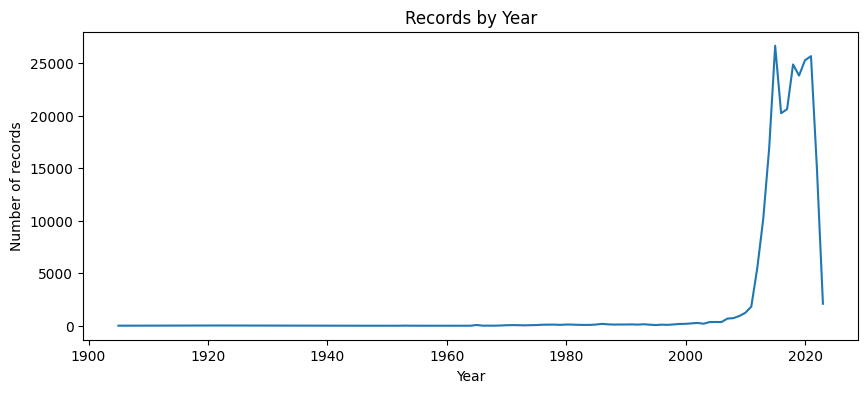

Start date year
1905        4
1922       22
1946        1
1948        1
1950        2
        ...  
2019    23839
2020    25296
2021    25688
2022    14925
2023     2095
Name: count, Length: 75, dtype: int64

In [65]:
import matplotlib.pyplot as plt

year_counts = df["Start date year"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(year_counts.index, year_counts.values)
plt.title("Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of records")
plt.show()

year_counts


In [66]:

# Count records per year
year_counts = df["Start date year"].value_counts().sort_index()

year_df = year_counts.reset_index()
year_df.columns = ["Year", "Record Count"]

# IQR-based outlier detection
Q1 = year_df["Record Count"].quantile(0.25)
Q3 = year_df["Record Count"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

incorrect_years = year_df[year_df["Record Count"] < lower_bound]["Year"]

incorrect_years




Series([], Name: Year, dtype: int64)

In [67]:
df_clean = df[df["Start date year"] >= 2014].copy()


### Treatment of Early-Year Data as Incorrect Input

Early years were not flagged as statistical outliers using IQR due to the
skewed temporal distribution of records. Visual inspection revealed that reliable data coverage begins in 2014. Earlier years were excluded as incomplete input data rather than genuine
temporal trends.

In [68]:
import plotly.express as px

sample = df.sample(5000, random_state=42) if len(df) > 5000 else df

fig = px.scatter_mapbox(
    sample,
    lat="Latitude (WGS84)",
    lon="Longitude (WGS84)",
    hover_name="Common name",
    hover_data=["Scientific name", "Start date year", "State/Province"],
    zoom=4,
    height=600
)

fig.update_layout(mapbox_style="open-street-map", margin={"r":0,"t":0,"l":0,"b":0})
fig.show()


After restarting the kernel to install missing dependencies, all variables
were cleared and the data loading step was re-executed to restore the
analysis state.


In [ ]:
# Create a mapping from Order to Mammal Group
order_to_group = {
    "Carnivora": "Carnivores",
    "Artiodactyla": "Herbivores & Ungulates",
    "Perissodactyla": "Herbivores & Ungulates",
    "Rodentia": "Rodents",
    "Chiroptera": "Bats",
    "Eulipotyphla": "Insectivores & Small Mammals",
    "Lagomorpha": "Lagomorphs",
    "Cetacea": "Marine Mammals",
    "Pinnipedia": "Marine Mammals",
}

df["Mammal Group"] = df["Order"].map(order_to_group).fillna("Other Mammals")

df["Mammal Group"].value_counts()


Mammal groups were created by mapping taxonomic orders to broader ecological
categories. Groups that do not appear in the results reflect the absence or
low frequency of those orders in the dataset, rather than an error in the
grouping logic.

NOTE

In [70]:
group_counts = (
    df["Mammal Group"]
    .value_counts()
    .rename_axis("Mammal Group")
    .reset_index(name="Record Count")
)

group_counts


,Mammal Group,Record Count
0,Carnivores,50944
1,Rodents,47438
2,Other Mammals,42690
3,Lagomorphs,39958
4,Herbivores & Ungulates,26499
5,Bats,19778


* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

In [71]:
groups = [
    "Carnivores",
    "Rodents",
    "Other Mammals",
    "Lagomorphs",
    "Herbivores & Ungulates",
    "Bats",
]

yearly_group_counts = (
    df_clean[df_clean["Mammal Group"].isin(groups)]
    .groupby(["Start date year", "Mammal Group"])
    .size()
    .reset_index(name="records")
)

pivot = (
    yearly_group_counts
    .pivot(index="Start date year", columns="Mammal Group", values="records")
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for g in groups:
    if g in pivot.columns:
        plt.plot(pivot.index, pivot[g], marker="o", label=g)

plt.title("Yearly Reporting by Mammal Group (Cleaned Data)")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.legend(title="Mammal Group")
plt.grid(alpha=0.3)
plt.show()




KeyError: 'Mammal Group'

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)